In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import pandas as pd

from neural_reconstruction.algorithms.fragment_linking.linker import HierarchicalFragmentLinker
from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar

import skimage as ski
# from skimage.measure import label
# from skimage.restoration import rolling_ball
from scipy.spatial import KDTree

from xgboost import XGBClassifier
import joblib


In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/')
IMAGE_ID = 'S1140-2_a'
BASE_PATH = BASE_PATH / f'nas/jia/data/{IMAGE_ID}'

In [3]:
image      = cv2.imread(f'{BASE_PATH}/image.png',      cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/mask.png',       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/weka.png', cv2.IMREAD_GRAYSCALE)

print(f'image      shape: {image.shape},      dtype: {image.dtype}')
print(f'mask       shape: {mask.shape},       dtype: {mask.dtype}')
print(f'annotation shape: {annotation.shape}, dtype: {annotation.dtype}')


image      shape: (1947, 4716),      dtype: uint8
mask       shape: (1947, 4716),       dtype: uint8
annotation shape: (1947, 4716), dtype: uint8


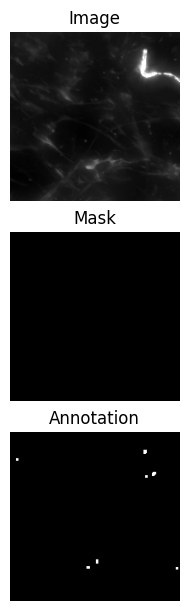

In [4]:
def crop(image:np.ndarray):
    x, y, w, h = 2825, 975 , 200, 200
    cropped_image = image[y:y+h, x:x+w]
    return cropped_image

roi_image = crop(image)
roi_mask = crop(mask)
roi_annotation = crop(annotation)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel)
roi_annotation[roi_annotation > 0] = 255
_, axes = plt.subplots(3, 1, figsize=(18, 6), constrained_layout=True)
axes[0].imshow(roi_image,      cmap='gray');  axes[0].set_title('Image');       axes[0].axis('off')
axes[1].imshow(roi_mask,       cmap='gray');  axes[1].set_title('Mask');        axes[1].axis('off')
axes[2].imshow(roi_annotation, cmap='gray');  axes[2].set_title('Annotation');  axes[2].axis('off')
plt.show()

# Skeleton Graph

In [5]:
builder = TopologyBuilder(segment_length=1.0)
skeleton = builder.build_skeleton_graph(roi_annotation, roi_image)

print(f'Nodes: {skeleton.number_of_nodes()}')
print(f'Edges: {skeleton.number_of_edges()}')
degrees = dict(skeleton.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Nodes: 7
Edges: 0
Endpoints (degree=1): 0
Junctions (degree>=3): 0
Isolated  (degree=0): 7


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [6]:
def draw_graph_on_image(ax, graph, bg_image, title='', cmap='gray',
                        node_size=6, edge_alpha=0.8, color_by_distance=True):
    """Overlay a skeleton/seed graph on a background image."""
    ax.imshow(bg_image, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

    if graph.number_of_edges() == 0 and graph.number_of_nodes() == 0:
        return

    # --- edges ---
    if color_by_distance and graph.number_of_edges() > 0:
        distances = [d.get('branch-distance', 0) for _, _, d in graph.edges(data=True)]
        vmin, vmax = min(distances), max(distances)
        cmap_edge = plt.cm.plasma
        norm = plt.Normalize(vmin=vmin, vmax=max(vmax, 1e-6))

    for u, v, data in graph.edges(data=True):
        path = data.get('path', [u, v])
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        if color_by_distance:
            color = cmap_edge(norm(data.get('branch-distance', 0)))
        else:
            color = 'cyan'
        ax.plot(xs, ys, color=color, linewidth=1.2, alpha=edge_alpha)

    # --- nodes: coloured by degree ---
    for node in graph.nodes():
        y, x = node
        deg = graph.degree(node)
        if deg == 0:
            color, zorder, size = 'yellow', 4, node_size * 1.5   # isolated
        elif deg == 1:
            color, zorder, size = 'red',    4, node_size          # endpoint
        elif deg == 2:
            color, zorder, size = 'lime',   3, node_size * 0.7   # chain (should be merged)
        else:
            color, zorder, size = 'blue',   5, node_size * 1.4   # junction
        ax.scatter(x, y, c=color, s=size**2, zorder=zorder, linewidths=0)

    # colorbar for edge distance
    if color_by_distance and graph.number_of_edges() > 0:
        sm = plt.cm.ScalarMappable(cmap=cmap_edge, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01, label='branch-distance (px)')

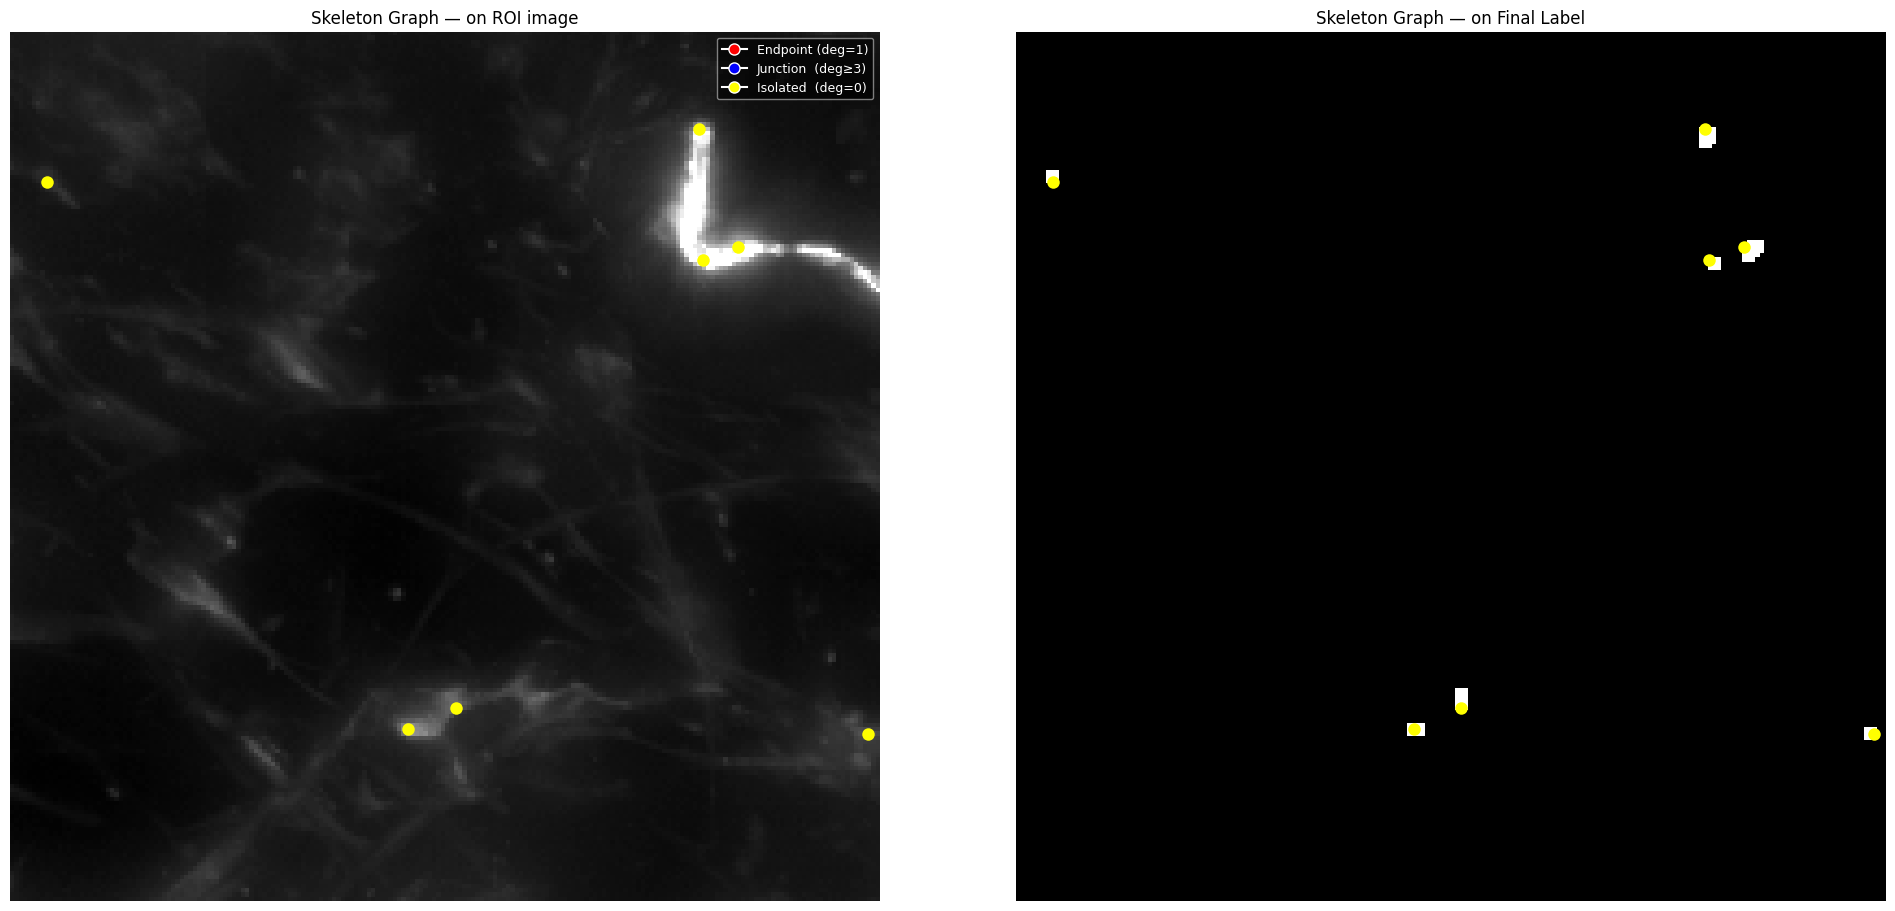

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
draw_graph_on_image(axes[0], skeleton, roi_image,
                    title='Skeleton Graph — on ROI image', color_by_distance=True)
draw_graph_on_image(axes[1], skeleton, roi_annotation,
                    title='Skeleton Graph — on Final Label', color_by_distance=False)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Endpoint (deg=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=8, label='Junction  (deg≥3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Isolated  (deg=0)'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')
plt.show()

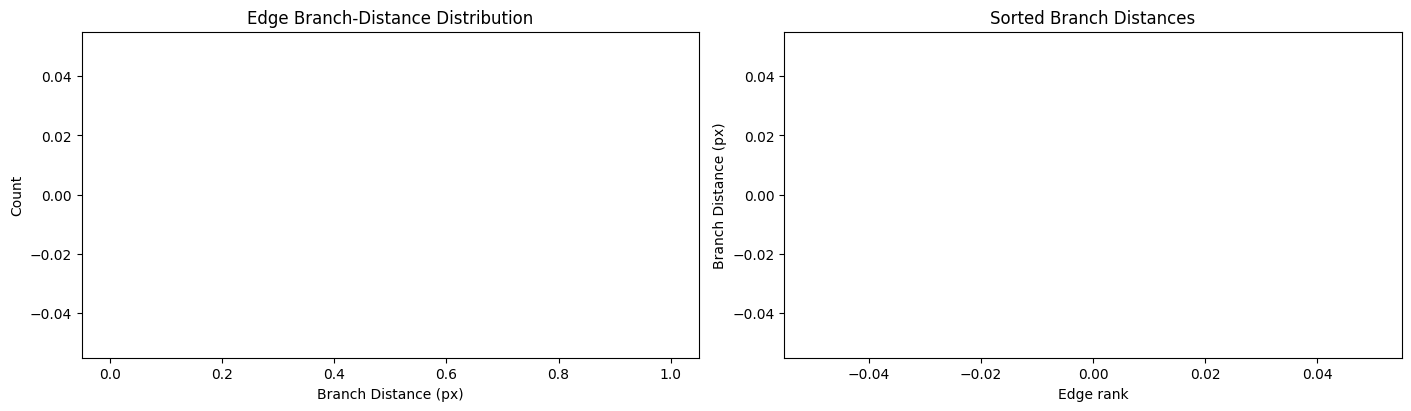

count       0
unique      0
top       NaN
freq      NaN


In [8]:
# Branch-distance distribution
edge_distances = [d.get('branch-distance', 0) for _, _, d in skeleton.edges(data=True)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

axes[0].hist(edge_distances, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Branch Distance (px)')
axes[0].set_ylabel('Count')
axes[0].set_title('Edge Branch-Distance Distribution')

sorted_d = sorted(edge_distances)
axes[1].plot(sorted_d, color='steelblue')
axes[1].set_xlabel('Edge rank')
axes[1].set_ylabel('Branch Distance (px)')
axes[1].set_title('Sorted Branch Distances')

plt.show()

print(pd.Series(edge_distances, name='branch-distance').describe().to_string())

In [9]:
for u, v, data in skeleton.edges(data=True):
    is_hang = (skeleton.degree(u) == 1 and skeleton.degree(v) >= 2) or (
              skeleton.degree(v) == 1 and skeleton.degree(u) >= 2)
    is_short = data.get('branch-distance', 0) < 5
    if is_hang and is_short:
        print(f'Hang edge: {u} - {v}, branch-distance: {data.get("branch-distance", 0)}')

# Seed Graph

In [10]:
seed = builder.build_seed_graph(roi_annotation , roi_image)

print(f'Skeleton → Seed')
print(f'  Nodes:  {skeleton.number_of_nodes():>5}  →  {seed.number_of_nodes()}')
print(f'  Edges:  {skeleton.number_of_edges():>5}  →  {seed.number_of_edges()}')
degrees = dict(seed.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Skeleton → Seed
  Nodes:      7  →  7
  Edges:      0  →  0
Endpoints (degree=1): 0
Junctions (degree>=3): 0
Isolated  (degree=0): 7


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [11]:
# print node of degree larger than 3 
for node, deg in seed.degree():
    if deg >= 3:
        print(f'Node {node} has degree {deg}')
        for neighbor in seed.neighbors(node):
            print(f'  Neighbor {neighbor} has degree {seed.degree(neighbor)}')

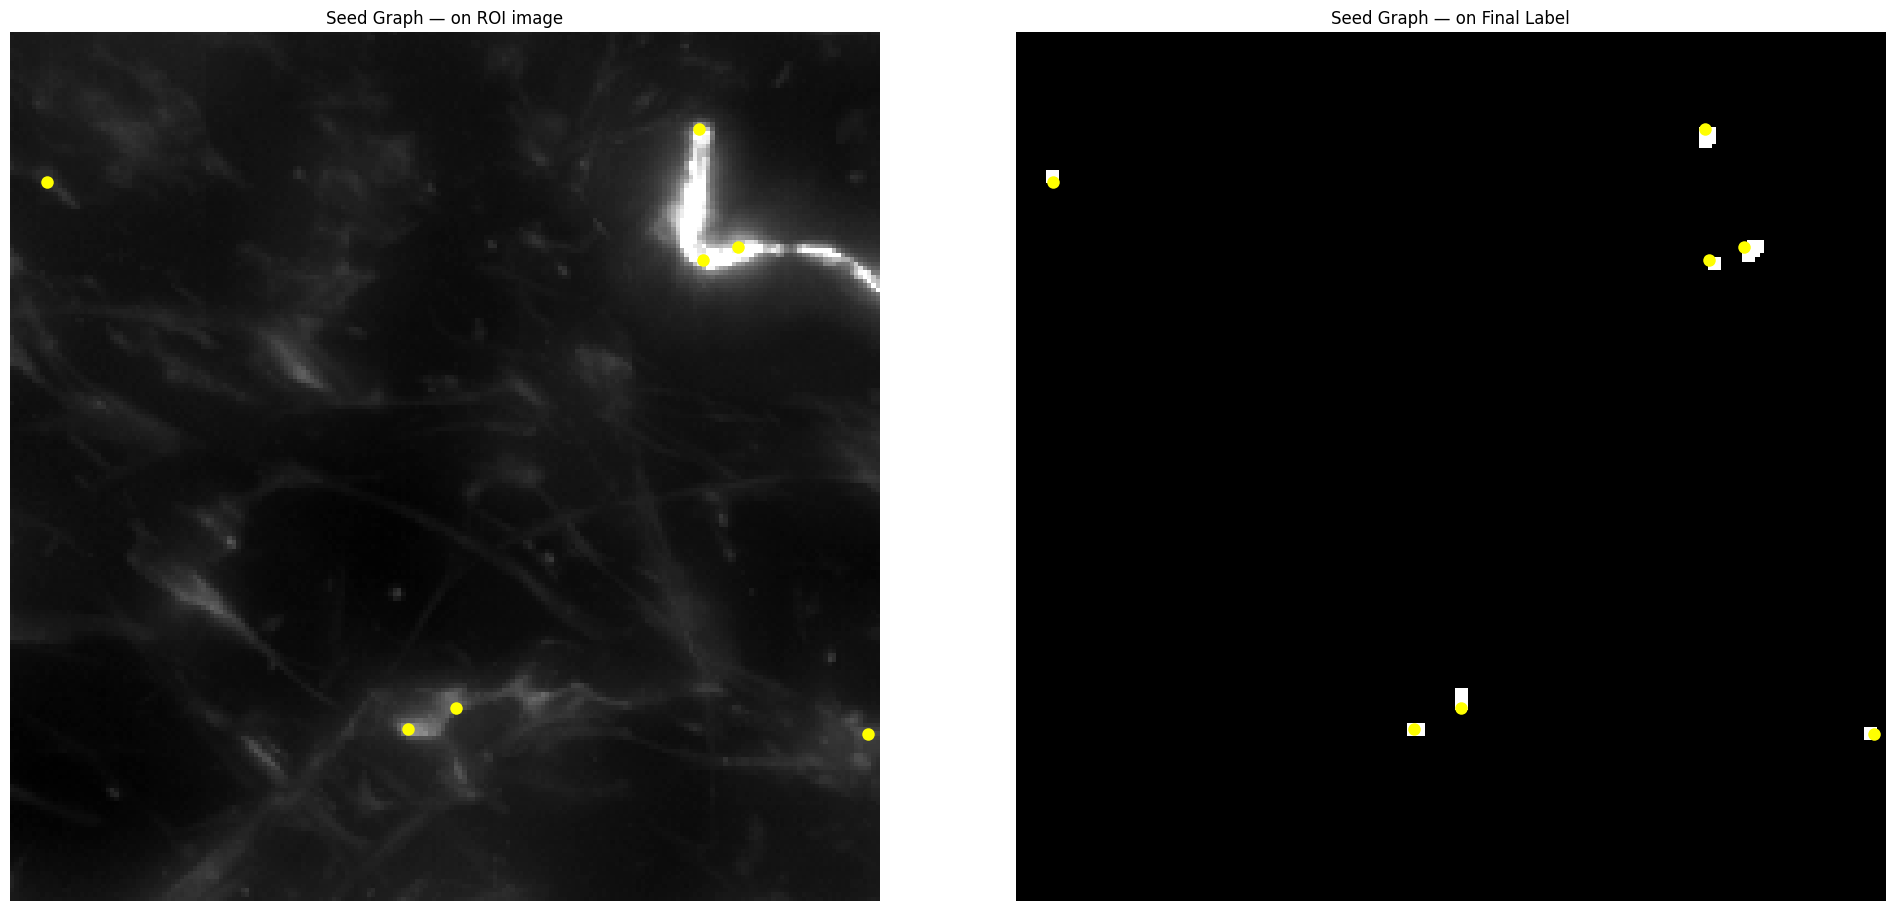

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
draw_graph_on_image(axes[0], seed, roi_image,
                    title='Seed Graph — on ROI image', color_by_distance=False)
draw_graph_on_image(axes[1], seed, roi_annotation,
                    title='Seed Graph — on Final Label', color_by_distance=False)
plt.show()

# Skeleton vs Seed — Side-by-Side Comparison

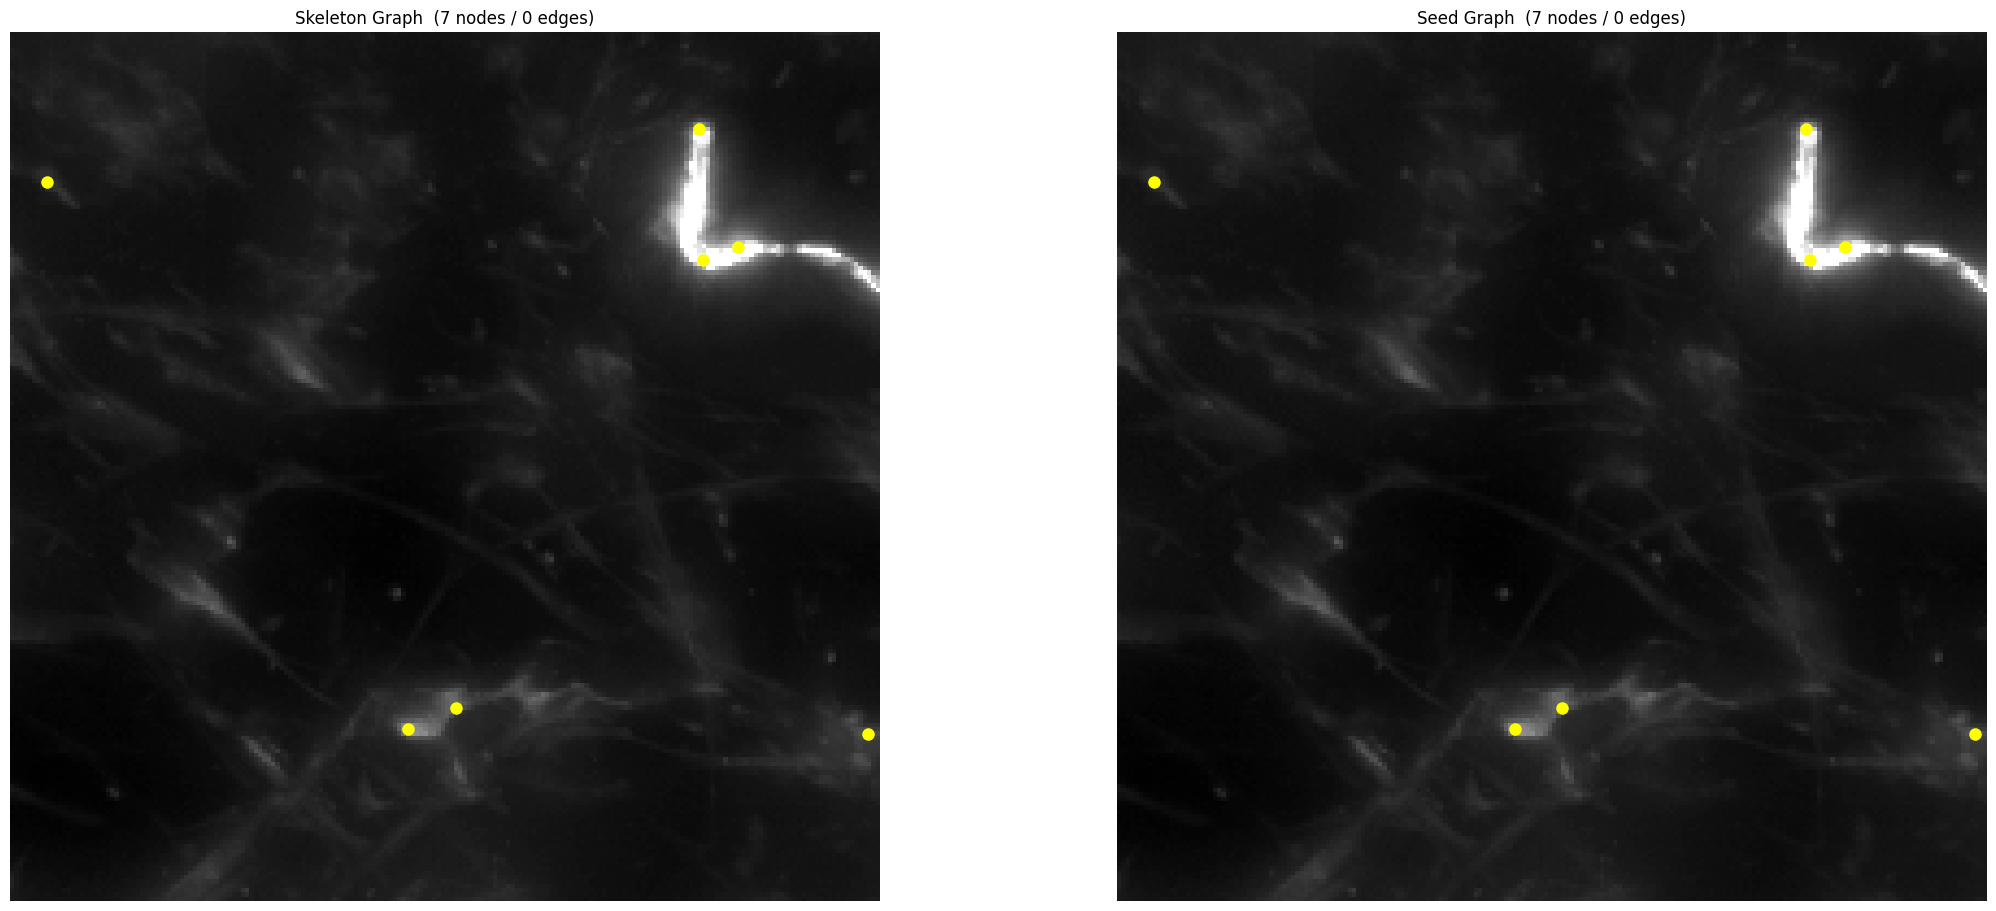

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9), constrained_layout=True)
draw_graph_on_image(axes[0], skeleton, roi_image,
                    title=f'Skeleton Graph  ({skeleton.number_of_nodes()} nodes / {skeleton.number_of_edges()} edges)',
                    color_by_distance=True)
draw_graph_on_image(axes[1], seed, roi_image,
                    title=f'Seed Graph  ({seed.number_of_nodes()} nodes / {seed.number_of_edges()} edges)',
                    color_by_distance=False)
plt.show()

# Segment Length Sensitivity

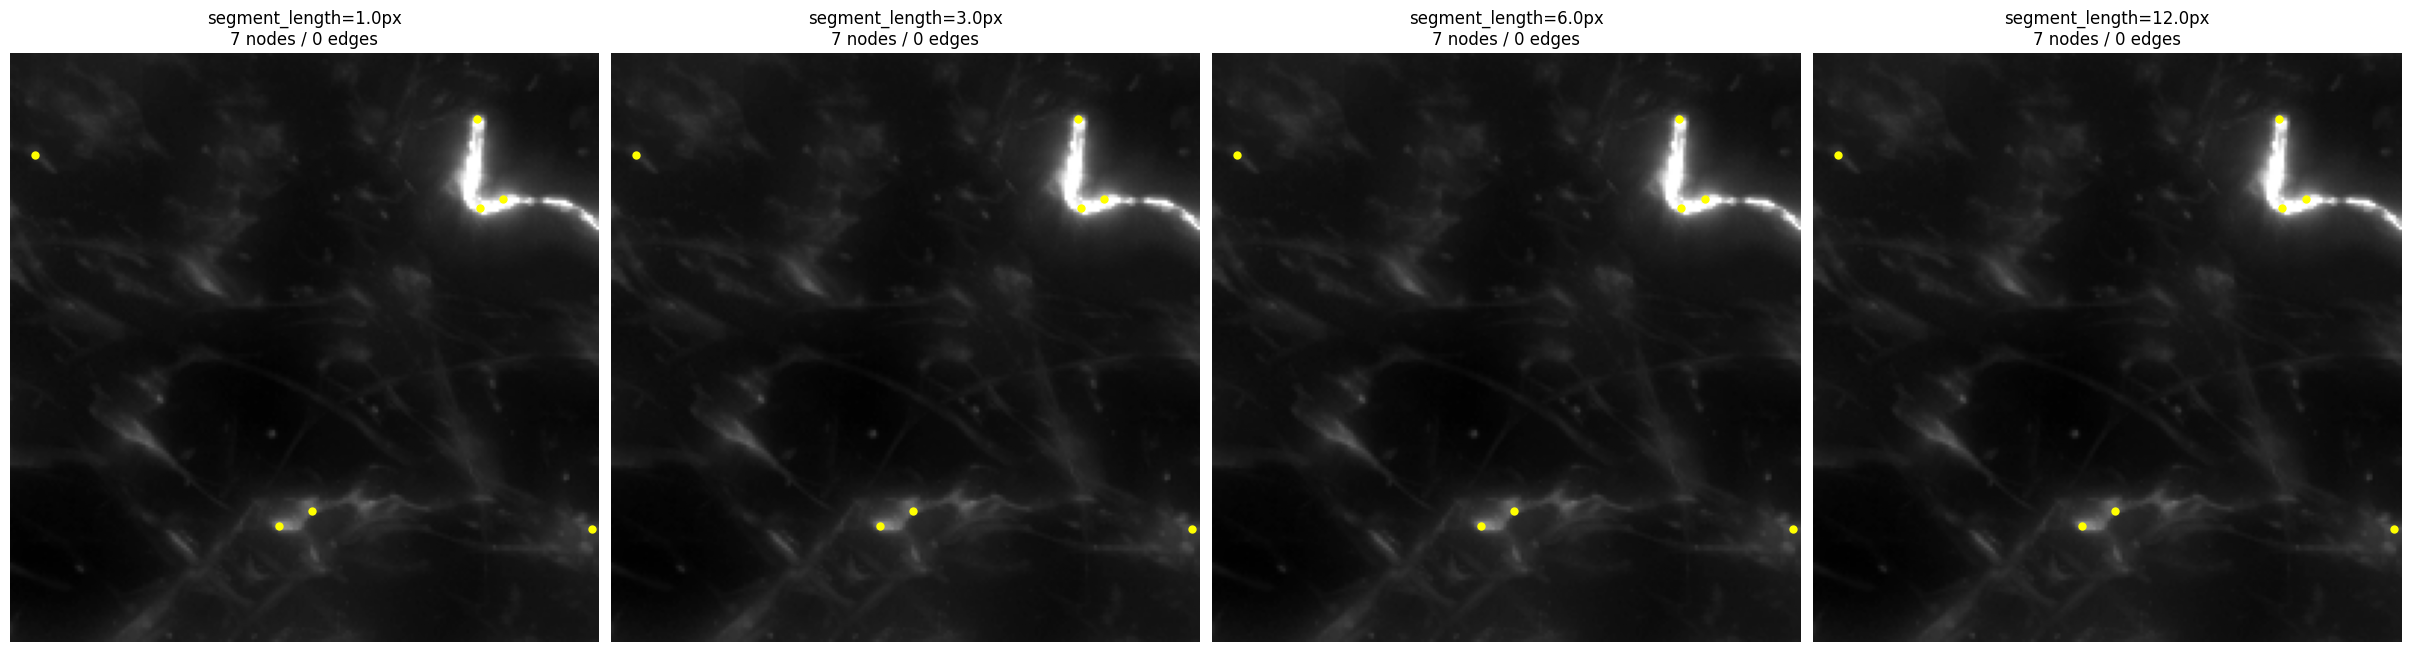

In [14]:
segment_lengths = [1.0, 3.0, 6.0, 12.0]
seeds = {sl: TopologyBuilder(segment_length=sl).build_seed_graph(roi_annotation, roi_image)
         for sl in segment_lengths}

fig, axes = plt.subplots(1, len(segment_lengths), figsize=(24, 7), constrained_layout=True)
for ax, sl in zip(axes, segment_lengths):
    g = seeds[sl]
    draw_graph_on_image(ax, g, roi_image,
                        title=f'segment_length={sl}px\n{g.number_of_nodes()} nodes / {g.number_of_edges()} edges',
                        color_by_distance=False, node_size=4, edge_alpha=0.7)
plt.show()